# 01 Explore the data

Goal of this notebook: before building any model, find out what the data looks like.
- How many wafers, how big is one map, what do the numbers mean?
- What do the defect patterns look like?
- How many examples of each class are there?

Dataset: MixedWM38, see `data/README.md` for where to download it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from collections import Counter

print("PyTorch", torch.__version__, "| GPU:", torch.cuda.is_available())

PyTorch 2.11.0+cu128 | GPU: True


## 1. Load the file

An `.npz` file is a zip with numpy arrays in it. This one has two:
`arr_0` holds the wafer maps, `arr_1` the labels.

In [3]:
# Relative path: the notebook runs from the notebooks folder, the data sits one folder up.
data = np.load("../data/Wafer_Map_Datasets.npz")
print(data.files)

maps = data["arr_0"]    # the wafer maps
labels = data["arr_1"]  # 8 labels per wafer

print("maps:  ", maps.shape, maps.dtype)
print("labels:", labels.shape, labels.dtype)

['arr_0', 'arr_1']
maps:   (38015, 52, 52) int32
labels: (38015, 8) int32


## 2. What do the numbers in a map mean?

Expected: 0 = no die (outside the round wafer), 1 = good die, 2 = failed die.
Check it instead of believing it.

In [4]:
values, counts = np.unique(maps, return_counts=True)
for v, c in zip(values, counts):
    print(f"value {v}: {c:,} pixels")

value 0: 24,349,490 pixels
value 1: 53,392,308 pixels
value 2: 25,050,548 pixels
value 3: 214 pixels


## 3. Turn the label into a name

Each label is 8 numbers, one per single defect, 1 if it is on the wafer.
All zeros means a normal wafer. More than one 1 means a mixed defect.

In [5]:
# The column order comes from the dataset description.
DEFECTS = ["Center", "Donut", "Edge-Loc", "Edge-Ring", "Loc", "Near-Full", "Scratch", "Random"]

def label_name(label):
    # Collect the names of every defect that is switched on.
    present = [DEFECTS[i] for i in range(8) if label[i] == 1]
    if not present:
        return "Normal"
    return " + ".join(present)

print(labels[0], "->", label_name(labels[0]))

[1 0 1 0 0 0 1 0] -> Center + Edge-Loc + Scratch


## 4. Look at one wafer

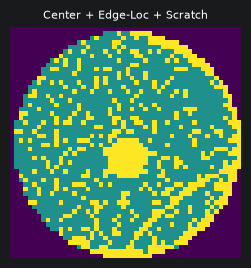

In [6]:
def show_wafer(ax, wafer_map, title):
    # Three colours for the three values: background, good, failed.
    ax.imshow(wafer_map, cmap="viridis", vmin=0, vmax=2)
    ax.set_title(title, fontsize=8)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(3, 3))
show_wafer(ax, maps[0], label_name(labels[0]))
plt.show()

## 5. One example of every single defect

Pick the first wafer that has exactly that one defect, so you see each pattern on its own.

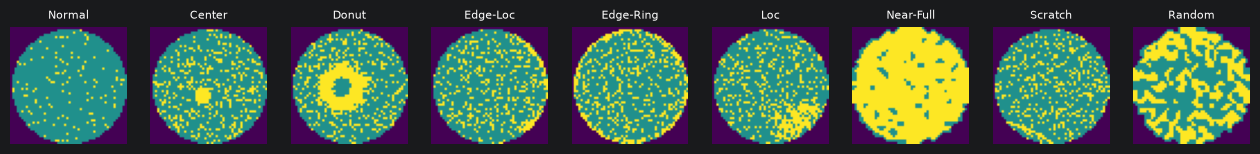

In [7]:
fig, axes = plt.subplots(1, 9, figsize=(16, 2.5))

# Normal first: a wafer with no defect at all.
normal = np.where(labels.sum(axis=1) == 0)[0][0]
show_wafer(axes[0], maps[normal], "Normal")

for i, name in enumerate(DEFECTS):
    # Exactly one defect, and it is this one.
    only_this = np.where((labels.sum(axis=1) == 1) & (labels[:, i] == 1))[0]
    show_wafer(axes[i + 1], maps[only_this[0]], name)

plt.show()

## 6. How many of each class?

Every combination of defects counts as its own class. The paper says 38.
If some classes are much smaller than others, the model will have trouble with them later.

In [8]:
names = [label_name(l) for l in labels]
class_counts = Counter(names)

print("number of classes:", len(class_counts))
for name, n in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"{n:6,}  {name}")

number of classes: 38
 2,000  Center + Edge-Loc + Scratch
 1,000  Center + Edge-Loc
 1,000  Center + Edge-Ring + Scratch
 1,000  Center + Edge-Ring
 1,000  Center + Edge-Loc + Loc + Scratch
 1,000  Center + Edge-Loc + Loc
 1,000  Center + Edge-Ring + Loc + Scratch
 1,000  Center + Edge-Ring + Loc
 1,000  Center + Loc + Scratch
 1,000  Center + Loc
 1,000  Center + Scratch
 1,000  Center
 1,000  Donut + Edge-Loc + Scratch
 1,000  Donut + Edge-Loc
 1,000  Donut + Edge-Ring + Scratch
 1,000  Donut + Edge-Ring
 1,000  Donut + Edge-Loc + Loc + Scratch
 1,000  Donut + Edge-Loc + Loc
 1,000  Donut + Edge-Ring + Loc + Scratch
 1,000  Donut + Edge-Ring + Loc
 1,000  Donut + Loc + Scratch
 1,000  Donut + Loc
 1,000  Donut + Scratch
 1,000  Donut
 1,000  Edge-Loc
 1,000  Edge-Ring
 1,000  Edge-Loc + Loc + Scratch
 1,000  Edge-Loc + Loc
 1,000  Edge-Ring + Loc + Scratch
 1,000  Edge-Ring + Loc
 1,000  Loc + Scratch
 1,000  Loc
 1,000  Normal
 1,000  Edge-Loc + Scratch
 1,000  Edge-Ring + Scratch
 

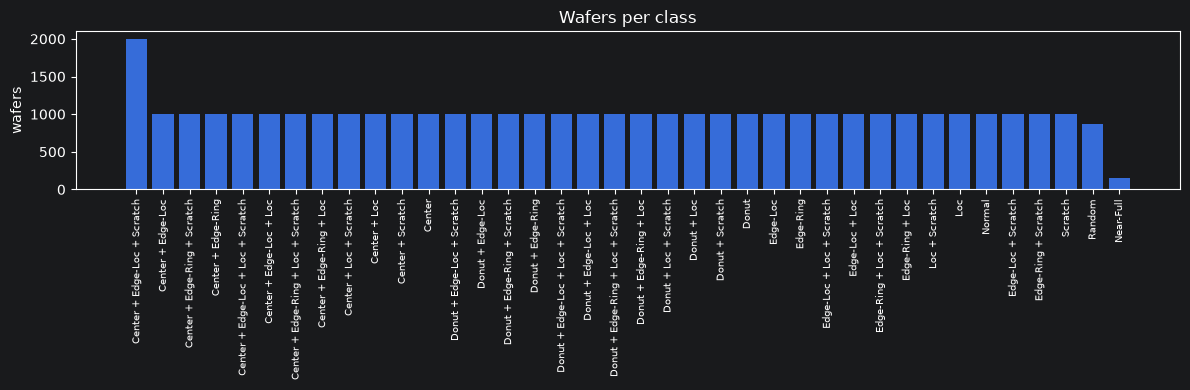

In [9]:
# The same as a chart, sorted from big to small.
sorted_counts = sorted(class_counts.items(), key=lambda x: -x[1])
plt.figure(figsize=(12, 4))
plt.bar([n for n, _ in sorted_counts], [c for _, c in sorted_counts])
plt.xticks(rotation=90, fontsize=7)
plt.ylabel("wafers")
plt.title("Wafers per class")
plt.tight_layout()
plt.show()

## 7. How many defects per wafer?

In [10]:
per_wafer = Counter(labels.sum(axis=1).astype(int))
for k in sorted(per_wafer):
    print(f"{k} defect(s): {per_wafer[k]:,} wafers")

0 defect(s): 1,000 wafers
1 defect(s): 7,015 wafers
2 defect(s): 13,000 wafers
3 defect(s): 13,000 wafers
4 defect(s): 4,000 wafers


## What I noticed

Write down what you saw, in your own words. This is input for your analyse and advise document.

-